In [1]:
# %% [markdown]
# # Pipeline Definitivo: Análisis sin Muestras 51 y 52 (Outliers)

# %%
library(DESeq2)
library(dplyr)
library(tibble)
library(ggplot2)
library(ggrepel)

# --- 0. RUTAS Y CARGA ---
base_dir <- "C:/Users/fran_/Documents/Doctorado/Inicios/Dani/GSE244241"

mat_raw_symbol <- read.csv(file.path(base_dir, "raw_counts_salmon_SYMBOLS.csv"), row.names = 1)
counts_int <- read.csv(file.path(base_dir, "MULTI_gene_expression_raw_counts.csv"), row.names = 1)

# --- 1. SUPER-MATRIZ ---
genes_comunes <- intersect(rownames(mat_raw_symbol), rownames(counts_int))
matriz_global <- round(cbind(mat_raw_symbol[genes_comunes, ], counts_int[genes_comunes, ]))
matriz_global <- matriz_global[!grepl("^ENSG", rownames(matriz_global)), ]

# ==========================================
# --- ¡NUEVO! EXTIRPAR MUESTRAS 51 y 52 ---
# ==========================================
muestras_out <- c("SRR26204551", "SRR26204552")
matriz_global <- matriz_global[, !(colnames(matriz_global) %in% muestras_out)]

cat("Columnas restantes después de limpiar:", ncol(matriz_global), "(Deberían ser 10)\n")

# --- 2. METADATA PERFECTA (Para 10 muestras) ---
metadata_global <- data.frame(
  row.names = colnames(matriz_global),
  Condicion = c(rep("Primigravida", 6), rep("Multigravida", 4)),
  TipoCelular = c("MIM", "HBC", "MIM", "HBC", "MIM", "HBC",  # Primi (6)
                  "MIM", "HBC", "MIM", "HBC"),               # Multi (Quedan 55, 56, 59, 60)
  Sexo = c(
    # PRIMI (49=M, 50=M, 53=M, 54=M, 57=F, 58=F)
    "Masculino", "Masculino", "Masculino", "Masculino", "Femenino", "Femenino",
    # MULTI (55=F, 56=F, 59=M, 60=M)
    "Femenino", "Femenino", "Masculino", "Masculino"
  )
)
metadata_global$Sexo <- factor(metadata_global$Sexo, levels = c("Masculino", "Femenino"))
metadata_global$Condicion <- factor(metadata_global$Condicion)
metadata_global$TipoCelular <- factor(metadata_global$TipoCelular)

# ==========================================
# --- 3. ANÁLISIS 1: MONOCITOS (MIM) ---
# ==========================================
muestras_mim <- metadata_global$TipoCelular == "MIM"
dds_mim <- DESeqDataSetFromMatrix(countData = matriz_global[, muestras_mim],
                                  colData = metadata_global[muestras_mim, ],
                                  design = ~ Condicion + Sexo)
dds_mim <- DESeq(dds_mim[rowSums(counts(dds_mim)) >= 10, ])
res_mim <- results(dds_mim, contrast = c("Sexo", "Femenino", "Masculino"))

degs_mim <- as.data.frame(res_mim) %>%
  rownames_to_column("Gene") %>%
  filter(padj < 0.05 & abs(log2FoldChange) > 0.58) %>%
  arrange(padj)

write.csv(degs_mim, file.path(base_dir, "DEGs_MIM_Global_SIN_51_52.csv"), row.names = FALSE)
cat("\nDEGs en Monocitos (MIM):", nrow(degs_mim), "\n")
if(nrow(degs_mim) > 0) print(head(degs_mim, 5))

# ==========================================
# --- 4. ANÁLISIS 2: HOFBAUER (HBC) ---
# ==========================================
muestras_hbc <- metadata_global$TipoCelular == "HBC"
dds_hbc <- DESeqDataSetFromMatrix(countData = matriz_global[, muestras_hbc],
                                  colData = metadata_global[muestras_hbc, ],
                                  design = ~ Condicion + Sexo)
dds_hbc <- DESeq(dds_hbc[rowSums(counts(dds_hbc)) >= 10, ])
res_hbc <- results(dds_hbc, contrast = c("Sexo", "Femenino", "Masculino"))

degs_hbc <- as.data.frame(res_hbc) %>%
  rownames_to_column("Gene") %>%
  filter(padj < 0.05 & abs(log2FoldChange) > 0.58) %>%
  arrange(padj)

write.csv(degs_hbc, file.path(base_dir, "DEGs_HBC_Global_SIN_51_52.csv"), row.names = FALSE)
cat("\nDEGs en Hofbauer (HBC):", nrow(degs_hbc), "\n")


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The follo

Columnas restantes después de limpiar: 10 (Deberían ser 10)


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing




DEGs en Monocitos (MIM): 34 
    Gene  baseMean log2FoldChange     lfcSE       stat       pvalue
1  DDX3Y 1195.1289      -8.646473 0.7304318 -11.837481 2.498454e-32
2 RPS4Y1 1273.7141      -9.424509 0.9853886  -9.564256 1.130116e-21
3  USP9Y  437.4398      -6.956614 0.8817867  -7.889225 3.040683e-15
4    ZFY  239.9282      -8.337048 1.0548582  -7.903477 2.712292e-15
5 EIF1AY  477.8293      -7.155811 0.9189249  -7.787156 6.853446e-15
          padj
1 4.316079e-28
2 9.761380e-18
3 1.313195e-11
4 1.313195e-11
5 2.367866e-11


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing




DEGs en Hofbauer (HBC): 22 


In [2]:
# %% [markdown]
# # Análisis Exclusivo para HBC (Hofbauer) - Sexo Actualizado

# %%
# 1. AISLAR CÉLULAS DE HOFBAUER (HBC)
muestras_hbc <- metadata_global$TipoCelular == "HBC"
matriz_hbc <- matriz_global[, muestras_hbc]
meta_hbc <- metadata_global[muestras_hbc, ]

# 2. CORRER DESeq2 (Solo para HBC)
dds_hbc_global <- DESeqDataSetFromMatrix(countData = matriz_hbc,
                                         colData = meta_hbc,
                                         design = ~ Condicion + Sexo)

# Filtro de calidad (chau genes con menos de 10 lecturas en total)
dds_hbc_global <- dds_hbc_global[rowSums(counts(dds_hbc_global)) >= 10, ]

# Motor estadístico
dds_hbc_global <- DESeq(dds_hbc_global)
res_hbc_global <- results(dds_hbc_global, contrast = c("Sexo", "Femenino", "Masculino"))

# 3. EXTRACCIÓN DE RESULTADOS (Filtro relajado log2FC > 0.58)
degs_hbc_global <- as.data.frame(res_hbc_global) %>%
  rownames_to_column("Gene") %>%
  filter(padj < 0.05 & abs(log2FoldChange) > 0.58) %>%
  arrange(padj) # Los más significativos arriba

# 4. MOSTRAR EN PANTALLA
cat("\n--- DEGs en HBC (Muestra 51 Femenina) ---\n")
cat("Total encontrados:", nrow(degs_hbc_global), "\n")
print(head(degs_hbc_global, 10))

# 5. GUARDAR CSV
write.csv(degs_hbc_global, file.path(base_dir, "DEGs_HBC_Global_Fem_vs_Masc_ACTUALIZADO.csv"), row.names = FALSE)

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing




--- DEGs en HBC (Muestra 51 Femenina) ---
Total encontrados: 22 
     Gene  baseMean log2FoldChange     lfcSE       stat       pvalue
1   DDX3Y 1458.1832      -7.279281 0.5947519 -12.239189 1.919406e-34
2    PAEP  806.0695       5.075854 0.5961345   8.514611 1.671501e-17
3  RPS4Y1  502.8255      -5.385056 0.6489039  -8.298695 1.052615e-16
4   USP9Y  284.6053      -5.436845 0.6610036  -8.225137 1.949679e-16
5   KDM5D  285.7257      -5.350128 0.6710137  -7.973202 1.546152e-15
6     UTY  161.0681      -5.512926 0.8482188  -6.499415 8.063277e-11
7  EIF1AY  120.2644      -4.625147 0.7173388  -6.447647 1.136001e-10
8    PSG4 2010.3966      -3.083717 0.5166212  -5.969010 2.386975e-09
9  TXLNGY  167.1975      -7.124547 1.1953243  -5.960346 2.517039e-09
10    ZFY  123.1224      -8.089585 1.4603435  -5.539508 3.033224e-08
           padj
1  3.870865e-30
2  1.685458e-13
3  7.076030e-13
4  9.829794e-13
5  6.236251e-12
6  2.710202e-07
7  3.272820e-07
8  5.640126e-06
9  5.640126e-06
10 6.117103e-05



clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan,
X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal
enrichment tool for interpreting omics data. The Innovation. 2021,
2(3):100141


Attaching package: 'clusterProfiler'


The following object is masked from 'package:IRanges':

    slice


The following object is masked from 'package:S4Vectors':

    rename


The following object is masked from 'package:stats':

    filter


Loading required package: AnnotationDbi


Attaching package: 'AnnotationDbi'


The following object is masked from 'package:clusterProfiler':

    select


The following object is masked from 'package:dplyr':

    select




enrichplot v1.30.5 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Qianwen Wang, Ming Li, Tianzhi Wu, Li Zhan, Lin Li, Meijun Chen, Wenqin
Xie, Zijing Xie, Erqiang Hu, Shuan

Cantidad de genes ingresados al análisis: 14 

Vías biológicas encontradas: 150 
                   ID
GO:0019730 GO:0019730
GO:0019731 GO:0019731
GO:0009620 GO:0009620
GO:0050829 GO:0050829
GO:0006959 GO:0006959
GO:0050900 GO:0050900
GO:0050832 GO:0050832
GO:0031640 GO:0031640
GO:0061844 GO:0061844
GO:0141061 GO:0141061
                                                                       Description
GO:0019730                                          antimicrobial humoral response
GO:0019731                                          antibacterial humoral response
GO:0009620                                                      response to fungus
GO:0050829                             defense response to Gram-negative bacterium
GO:0006959                                                 humoral immune response
GO:0050900                                                     leukocyte migration
GO:0050832                                              defense response to fungus
GO:0031640   

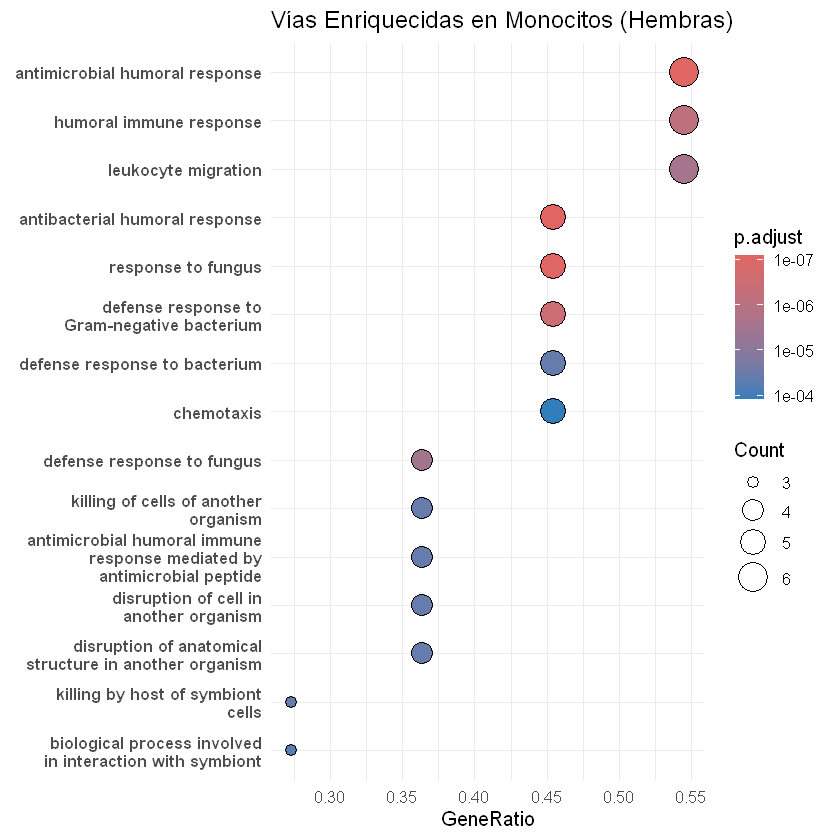

In [5]:
# %% [markdown]
# # Análisis de Vías (Pathways - Gene Ontology) en Monocitos

# %%
# Cargar librerías necesarias
library(clusterProfiler)
library(org.Hs.eg.db) # Base de datos del genoma humano
library(enrichplot)
library(ggplot2)

# 1. Aislar los genes de interés
# Vamos a agarrar los genes significativos de MIM que están sobreexpresados en Femenino (LFC > 0.58)
# y vamos a EXCLUIR los del cromosoma X para ver el efecto autosómico puro.
genes_fem_mim <- degs_mim %>%
  filter(log2FoldChange > 0.58 & !Gene %in% c("XIST", "TSIX")) %>% # Excluimos los clásicos del X por las dudas
  pull(Gene)

cat("Cantidad de genes ingresados al análisis:", length(genes_fem_mim), "\n")

# 2. Correr el Análisis de Enriquecimiento (GO - Biological Process)
ego_mim_fem <- enrichGO(gene          = genes_fem_mim,
                        OrgDb         = org.Hs.eg.db,
                        keyType       = "SYMBOL", # Le decimos que usamos nombres de genes
                        ont           = "BP",     # BP = Procesos Biológicos
                        pAdjustMethod = "BH",
                        pvalueCutoff  = 0.05,
                        qvalueCutoff  = 0.2,
                        readable      = TRUE)

# 3. Ver los resultados en tabla
res_pathways <- as.data.frame(ego_mim_fem)
cat("\nVías biológicas encontradas:", nrow(res_pathways), "\n")
if(nrow(res_pathways) > 0) {
  print(head(res_pathways[, c("ID", "Description", "p.adjust", "Count")], 10))
} else {
  cat("La lista es muy cortita y el programa fue muy estricto. ¡Avisame si sale 0!\n")
}

# 4. Graficar el clásico "Dotplot" de paper
if(nrow(res_pathways) > 0) {
  grafico_vias <- dotplot(ego_mim_fem, showCategory = 15, title = "Vías Enriquecidas en Monocitos (Hembras)") +
    theme_minimal(base_size = 12) +
    theme(axis.text.y = element_text(size = 10, face = "bold"))
  
  print(grafico_vias)
}

In [6]:
# %% [markdown]
# # Análisis de Inmunometabolismo por GSEA (Gene Set Enrichment Analysis)

# %%
library(clusterProfiler)
library(org.Hs.eg.db)
library(dplyr)
library(tibble)

# 1. Preparar la "Fila India" de genes (Ranked List)
# Usamos el resultado crudo de DESeq2 (res_mim), SIN FILTRAR por p-valor
res_gsea <- as.data.frame(res_mim) %>%
  rownames_to_column("Gene") %>%
  filter(!is.na(stat)) %>%       # Sacamos los NA
  arrange(desc(stat))            # Ordenamos por el valor estadístico (positivo = Femenino, negativo = Masculino)

# Creamos el vector que necesita clusterProfiler
lista_ordenada <- res_gsea$stat
names(lista_ordenada) <- res_gsea$Gene

cat("Genes listos para el ranking:", length(lista_ordenada), "\n")

# 2. Correr GSEA para Procesos Biológicos (GO)
# Ojo: Esto puede tardar 1 o 2 minutitos porque procesa miles de vías
set.seed(123) # Para que sea reproducible
gsea_go <- gseGO(geneList     = lista_ordenada,
                 OrgDb        = org.Hs.eg.db,
                 keyType      = "SYMBOL",
                 ont          = "BP", # Procesos Biológicos
                 minGSSize    = 15,
                 maxGSSize    = 500,
                 pvalueCutoff = 0.1,  # Somos un poco más flexibles para ver tendencias
                 verbose      = FALSE)

# 3. Convertir a tabla y BUSCAR METABOLISMO
res_gsea_df <- as.data.frame(gsea_go)

# Palabras clave en inglés (GO terms suelen estar en inglés)
palabras_clave <- "metabol|glycol|lipid|fatty acid|oxphos|mitochondri"

vias_metabolicas <- res_gsea_df %>%
  filter(grepl(palabras_clave, Description, ignore.case = TRUE)) %>%
  arrange(p.adjust)

cat("\n--- VÍAS INMUNOMETABÓLICAS ENCONTRADAS ---\n")
if(nrow(vias_metabolicas) > 0) {
  print(head(vias_metabolicas[, c("ID", "Description", "enrichmentScore", "p.adjust")], 15))
} else {
  cat("No saltaron vías metabólicas significativas con este corte.\n")
}

Genes listos para el ranking: 19550 


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.81% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA."
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation."



--- VÍAS INMUNOMETABÓLICAS ENCONTRADAS ---
                   ID
GO:0032543 GO:0032543
GO:0140053 GO:0140053
GO:0042775 GO:0042775
GO:0009100 GO:0009100
GO:0033108 GO:0033108
GO:0016072 GO:0016072
GO:0007005 GO:0007005
GO:0006091 GO:0006091
GO:0032963 GO:0032963
GO:0042776 GO:0042776
GO:0072655 GO:0072655
GO:0051204 GO:0051204
GO:0007007 GO:0007007
GO:0090151 GO:0090151
GO:0070585 GO:0070585
                                                               Description
GO:0032543                                       mitochondrial translation
GO:0140053                                   mitochondrial gene expression
GO:0042775          mitochondrial ATP synthesis coupled electron transport
GO:0009100                                  glycoprotein metabolic process
GO:0033108                mitochondrial respiratory chain complex assembly
GO:0016072                                          rRNA metabolic process
GO:0007005                                      mitochondrion organization
GO:0

In [7]:
# %% [markdown]
# # Análisis de Inmunometabolismo por GSEA en Hofbauer (HBC)

# %%
library(clusterProfiler)
library(org.Hs.eg.db)
library(dplyr)
library(tibble)

# 1. Preparar la "Fila India" de genes (Ranked List) para HBC
# Usamos el resultado crudo de DESeq2 (res_hbc)
res_gsea_hbc <- as.data.frame(res_hbc) %>%
  rownames_to_column("Gene") %>%
  filter(!is.na(stat)) %>%       # Limpiamos los NA
  arrange(desc(stat))            # Ordenamos por stat (positivo = Femenino, negativo = Masculino)

# Vector para clusterProfiler
lista_ordenada_hbc <- res_gsea_hbc$stat
names(lista_ordenada_hbc) <- res_gsea_hbc$Gene

cat("Genes de HBC listos para el ranking:", length(lista_ordenada_hbc), "\n")

# 2. Correr GSEA para Procesos Biológicos (GO)
set.seed(123) # Semilla para reproducibilidad
gsea_go_hbc <- gseGO(geneList     = lista_ordenada_hbc,
                     OrgDb        = org.Hs.eg.db,
                     keyType      = "SYMBOL",
                     ont          = "BP", 
                     minGSSize    = 15,
                     maxGSSize    = 500,
                     pvalueCutoff = 0.1,  # Permisivo para pescar vías metabólicas
                     verbose      = FALSE)

# 3. Convertir a tabla y BUSCAR METABOLISMO
res_gsea_hbc_df <- as.data.frame(gsea_go_hbc)

# Palabras clave de inmunometabolismo
palabras_clave <- "metabol|glycol|lipid|fatty acid|oxphos|mitochondri"

vias_metabolicas_hbc <- res_gsea_hbc_df %>%
  filter(grepl(palabras_clave, Description, ignore.case = TRUE)) %>%
  arrange(p.adjust)

cat("\n--- VÍAS INMUNOMETABÓLICAS EN HOFBAUER (HBC) ---\n")
if(nrow(vias_metabolicas_hbc) > 0) {
  print(head(vias_metabolicas_hbc[, c("ID", "Description", "enrichmentScore", "p.adjust")], 15))
} else {
  cat("No saltaron vías metabólicas significativas con este corte.\n")
}

Genes de HBC listos para el ranking: 20167 


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.73% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA."
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
"For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation."



--- VÍAS INMUNOMETABÓLICAS EN HOFBAUER (HBC) ---
                   ID                                  Description
GO:0090207 GO:0090207 regulation of triglyceride metabolic process
GO:0006639 GO:0006639               acylglycerol metabolic process
GO:0019915 GO:0019915                                lipid storage
GO:0006638 GO:0006638              neutral lipid metabolic process
GO:1905952 GO:1905952             regulation of lipid localization
GO:0006641 GO:0006641               triglyceride metabolic process
GO:1905954 GO:1905954    positive regulation of lipid localization
GO:0010876 GO:0010876                           lipid localization
GO:0010883 GO:0010883                  regulation of lipid storage
GO:0065005 GO:0065005               protein-lipid complex assembly
GO:0016042 GO:0016042                      lipid catabolic process
GO:1905953 GO:1905953    negative regulation of lipid localization
GO:0006869 GO:0006869                              lipid transport
GO:0032368 G

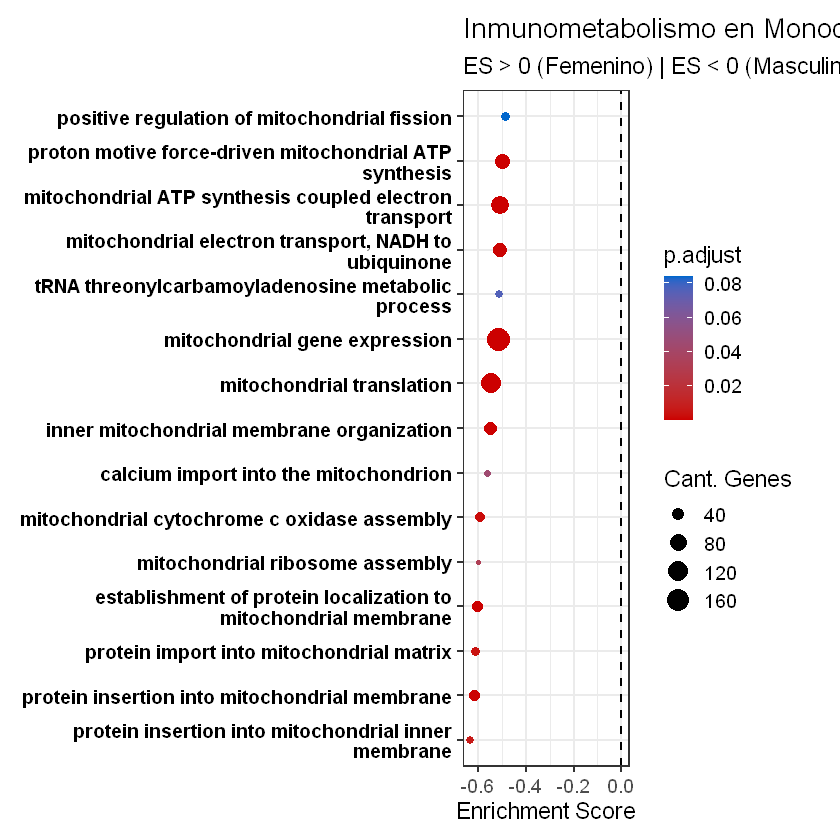

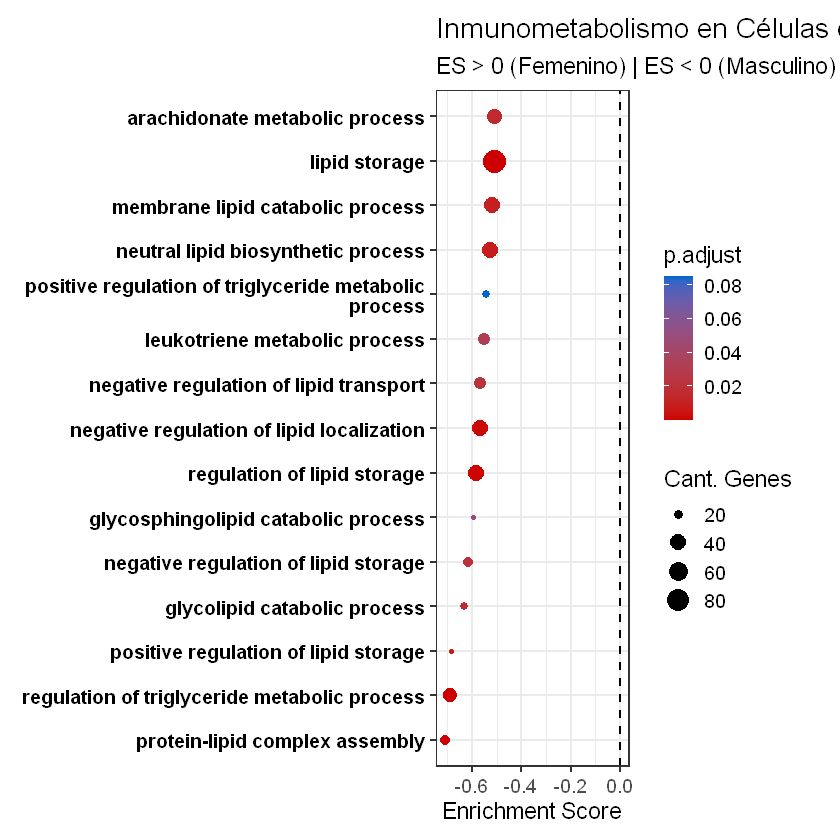

In [8]:
# %% [markdown]
# # Dotplots Inmunometabolismo (Ajuste de texto y exportación PDF)

# %%
library(ggplot2)
library(dplyr)
library(stringr) # <-- Clave para cortar los textos largos

# Palabras clave
palabras_clave <- "metabol|glycol|lipid|fatty acid|oxphos|mitochondri"

# ==========================================
# 1. DOTPLOT PARA MONOCITOS (MIM)
# ==========================================
df_mim_meta <- as.data.frame(gsea_go) %>%
  filter(grepl(palabras_clave, Description, ignore.case = TRUE)) %>%
  arrange(enrichmentScore) %>% 
  head(15)

# Magia: Envolvemos el texto a 45 caracteres máximo por línea
df_mim_meta$Description <- str_wrap(df_mim_meta$Description, width = 45)
df_mim_meta$Description <- factor(df_mim_meta$Description, levels = df_mim_meta$Description)

dotplot_mim <- ggplot(df_mim_meta, aes(x = enrichmentScore, y = Description)) +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#CC0000", high = "#0066CC") + 
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  theme_bw(base_size = 14) +
  labs(title = "Inmunometabolismo en Monocitos (MIM)",
       subtitle = "ES > 0 (Femenino) | ES < 0 (Masculino)",
       x = "Enrichment Score", y = "",
       size = "Cant. Genes", color = "p.adjust") +
  theme(axis.text.y = element_text(face = "bold", color = "black"),
        plot.margin = margin(10, 20, 10, 10)) # Margen extra a la derecha

print(dotplot_mim)

# GUARDADO AUTOMÁTICO AL DISCO
ggsave(file.path(base_dir, "GSEA_Metabolismo_MIM.pdf"), plot = dotplot_mim, width = 10, height = 7, dpi = 300)


# ==========================================
# 2. DOTPLOT PARA HOFBAUER (HBC)
# ==========================================
df_hbc_meta <- as.data.frame(gsea_go_hbc) %>%
  filter(grepl(palabras_clave, Description, ignore.case = TRUE)) %>%
  arrange(enrichmentScore) %>% 
  head(15)

# Envolvemos el texto
df_hbc_meta$Description <- str_wrap(df_hbc_meta$Description, width = 45)
df_hbc_meta$Description <- factor(df_hbc_meta$Description, levels = df_hbc_meta$Description)

dotplot_hbc <- ggplot(df_hbc_meta, aes(x = enrichmentScore, y = Description)) +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#CC0000", high = "#0066CC") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  theme_bw(base_size = 14) +
  labs(title = "Inmunometabolismo en Células de Hofbauer (HBC)",
       subtitle = "ES > 0 (Femenino) | ES < 0 (Masculino)",
       x = "Enrichment Score", y = "",
       size = "Cant. Genes", color = "p.adjust") +
  theme(axis.text.y = element_text(face = "bold", color = "black"),
        plot.margin = margin(10, 20, 10, 10))

print(dotplot_hbc)

# GUARDADO AUTOMÁTICO AL DISCO
ggsave(file.path(base_dir, "GSEA_Metabolismo_HBC.pdf"), plot = dotplot_hbc, width = 10, height = 7, dpi = 300)

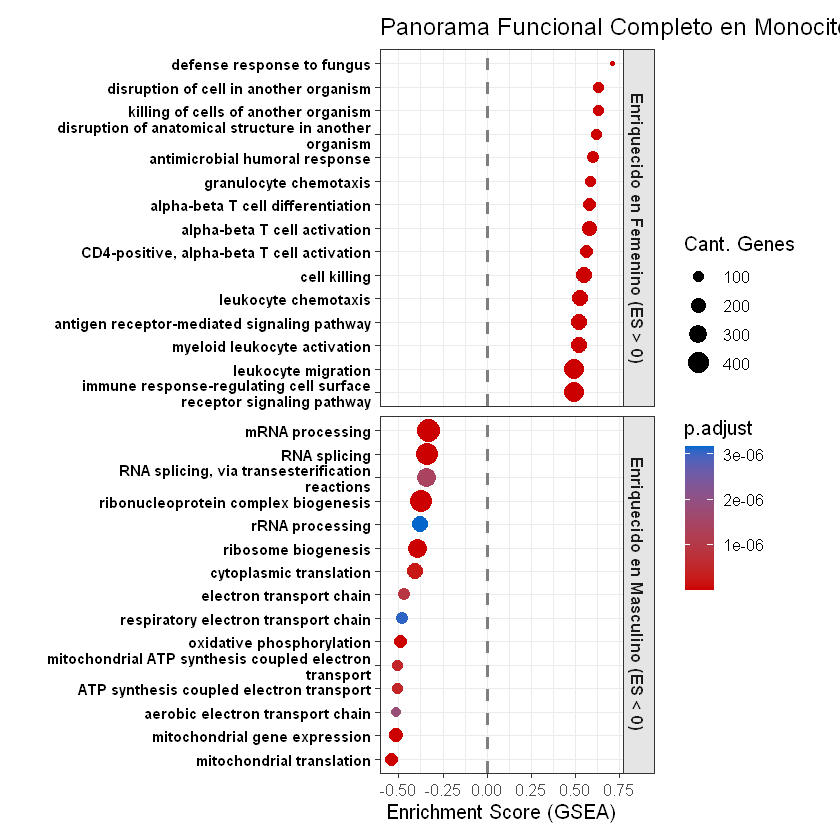

In [12]:
# %% [markdown]
# # Dotplot Equilibrado: Top 10 Femenino vs Top 10 Masculino (MIM)

# %%
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Convertimos el resultado general de MIM a tabla
df_gsea_all <- as.data.frame(gsea_go)

# 2. Rescatamos a las campeonas Femeninas (Enrichment Score Positivo)
top_fem <- df_gsea_all %>% 
  filter(enrichmentScore > 0) %>% 
  arrange(p.adjust) %>% 
  head(15) %>%
  mutate(Direccion = "Enriquecido en Femenino (ES > 0)")

# 3. Rescatamos a los campeones Masculinos (Enrichment Score Negativo)
top_masc <- df_gsea_all %>% 
  filter(enrichmentScore < 0) %>% 
  arrange(p.adjust) %>% 
  head(15) %>%
  mutate(Direccion = "Enriquecido en Masculino (ES < 0)")

# 4. Unimos las dos tablas y las ordenamos de negativo a positivo
df_balanceado <- bind_rows(top_fem, top_masc) %>%
  arrange(enrichmentScore)

# Envolvemos el texto largo para que no se corte
df_balanceado$Description <- str_wrap(df_balanceado$Description, width = 45)
df_balanceado$Description <- factor(df_balanceado$Description, levels = df_balanceado$Description)

# 5. Armamos el Super Dotplot
dotplot_balanceado <- ggplot(df_balanceado, aes(x = enrichmentScore, y = Description)) +
  # Línea central
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50", linewidth = 1) +
  # Puntos mapeados a tamaño y p-valor
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#CC0000", high = "#0066CC") +
  # Dividimos el gráfico en dos paneles (Hembras arriba, Machos abajo)
  facet_grid(Direccion ~ ., scales = "free_y", space = "free_y") +
  theme_bw(base_size = 12) +
  labs(title = "Panorama Funcional Completo en Monocitos (MIM)",
       x = "Enrichment Score (GSEA)", y = "",
       size = "Cant. Genes", color = "p.adjust") +
  theme(
    axis.text.y = element_text(face = "bold", color = "black", size = 9),
    strip.text.y = element_text(face = "bold", size = 10, angle = 270), # Texto lateral
    strip.background = element_rect(fill = "grey90"),
    plot.margin = margin(10, 20, 10, 10)
  )

print(dotplot_balanceado)



In [13]:
# Opcional: Guardarlo en tu compu
ggsave(file.path(base_dir, "GSEA_Balanceado_MIM.pdf"), plot = dotplot_balanceado, width = 11, height = 8)

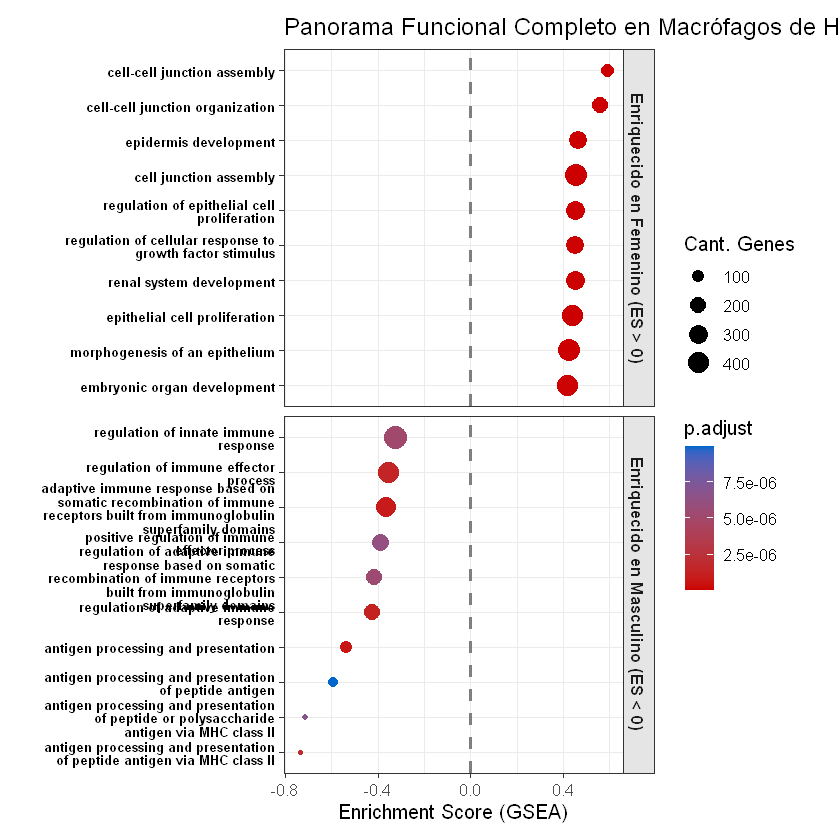

In [20]:
# %% [markdown]
# # Dotplot Equilibrado HBC (Ajuste de Texto y Tamaño)

# %%
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Tablas y unión (igual que antes)
df_gsea_hbc_all <- as.data.frame(gsea_go_hbc)

top_fem_hbc <- df_gsea_hbc_all %>% filter(enrichmentScore > 0) %>% arrange(p.adjust) %>% head(10) %>% mutate(Direccion = "Enriquecido en Femenino (ES > 0)")
top_masc_hbc <- df_gsea_hbc_all %>% filter(enrichmentScore < 0) %>% arrange(p.adjust) %>% head(10) %>% mutate(Direccion = "Enriquecido en Masculino (ES < 0)")
df_balanceado_hbc <- bind_rows(top_fem_hbc, top_masc_hbc) %>% arrange(enrichmentScore)

# 2. AJUSTE 1: Envolvemos el texto a menos caracteres (35) para que haga más saltos de línea
df_balanceado_hbc$Description <- str_wrap(df_balanceado_hbc$Description, width = 35)
df_balanceado_hbc$Description <- factor(df_balanceado_hbc$Description, levels = unique(df_balanceado_hbc$Description))

# 3. Gráfico con letras ajustadas
dotplot_balanceado_hbc <- ggplot(df_balanceado_hbc, aes(x = enrichmentScore, y = Description)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50", linewidth = 1) +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#CC0000", high = "#0066CC") +
  facet_grid(Direccion ~ ., scales = "free_y", space = "free_y") +
  theme_bw(base_size = 12) +
  labs(title = "Panorama Funcional Completo en Macrófagos de Hofbauer (HBC)",
       x = "Enrichment Score (GSEA)", y = "",
       size = "Cant. Genes", color = "p.adjust") +
  theme(
    # AJUSTE 2: Achicamos el tamaño de la letra del eje Y (de 9 a 7.5)
    axis.text.y = element_text(face = "bold", color = "black", size = 7.5),
    strip.text.y = element_text(face = "bold", size = 10, angle = 270), 
    strip.background = element_rect(fill = "grey90"),
    plot.margin = margin(10, 20, 10, 10)
  )

print(dotplot_balanceado_hbc)

# 4. AJUSTE 3: Agrandamos el PDF (height = 10)
ggsave(file.path(base_dir, "GSEA_Balanceado_HBC_FINAL.pdf"), plot = dotplot_balanceado_hbc, width = 11, height = 10, dpi = 300)

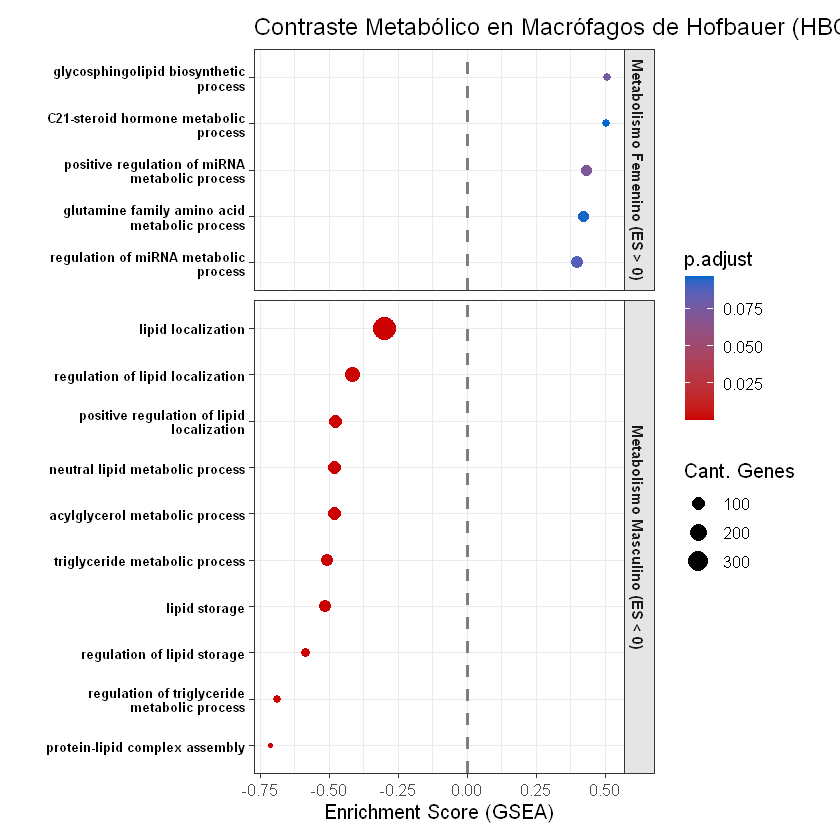

In [21]:
# %% [markdown]
# # Dotplot Equilibrado: SOLO Vías Metabólicas (HBC)

# %%
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Palabras clave de inmunometabolismo
palabras_clave <- "metabol|glycol|lipid|fatty acid|oxphos|mitochondri"

# 2. Filtramos TODO el GSEA de HBC buscando solo metabolismo
df_hbc_solo_meta <- as.data.frame(gsea_go_hbc) %>%
  filter(grepl(palabras_clave, Description, ignore.case = TRUE))

# 3. Rescatamos el Top 10 Metabólico Femenino (ES > 0)
top_fem_meta <- df_hbc_solo_meta %>% 
  filter(enrichmentScore > 0) %>% 
  arrange(p.adjust) %>% 
  head(10) %>%
  mutate(Direccion = "Metabolismo Femenino (ES > 0)")

# 4. Rescatamos el Top 10 Metabólico Masculino (ES < 0)
top_masc_meta <- df_hbc_solo_meta %>% 
  filter(enrichmentScore < 0) %>% 
  arrange(p.adjust) %>% 
  head(10) %>%
  mutate(Direccion = "Metabolismo Masculino (ES < 0)")

# 5. Unimos y preparamos el texto
df_balanceado_meta <- bind_rows(top_fem_meta, top_masc_meta) %>%
  arrange(enrichmentScore)

# Envolvemos el texto a 35 caracteres para que no se corte
df_balanceado_meta$Description <- str_wrap(df_balanceado_meta$Description, width = 35)
df_balanceado_meta$Description <- factor(df_balanceado_meta$Description, levels = unique(df_balanceado_meta$Description))

# 6. Graficamos
dotplot_meta_balanceado <- ggplot(df_balanceado_meta, aes(x = enrichmentScore, y = Description)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50", linewidth = 1) +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#CC0000", high = "#0066CC") +
  facet_grid(Direccion ~ ., scales = "free_y", space = "free_y") +
  theme_bw(base_size = 12) +
  labs(title = "Contraste Metabólico en Macrófagos de Hofbauer (HBC)",
       x = "Enrichment Score (GSEA)", y = "",
       size = "Cant. Genes", color = "p.adjust") +
  theme(
    axis.text.y = element_text(face = "bold", color = "black", size = 8),
    strip.text.y = element_text(face = "bold", size = 9, angle = 270),
    strip.background = element_rect(fill = "grey90"),
    plot.margin = margin(10, 20, 10, 10)
  )

print(dotplot_meta_balanceado)

# GUARDADO AUTOMÁTICO AL DISCO
ggsave(file.path(base_dir, "GSEA_Solo_Metabolismo_HBC.pdf"), plot = dotplot_meta_balanceado, width = 11, height = 8, dpi = 300)

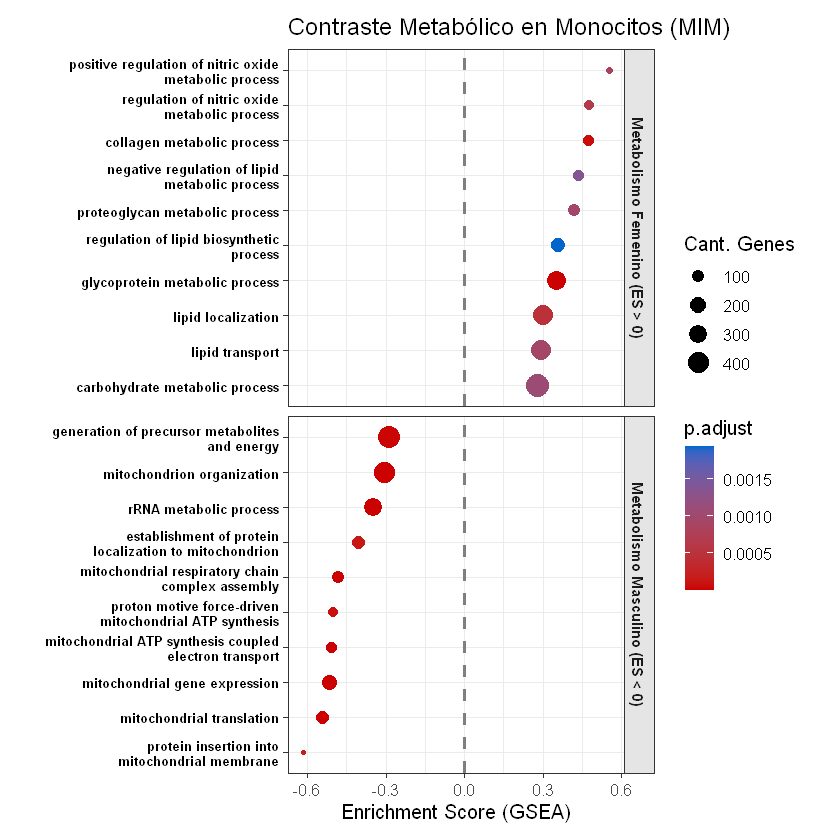

In [22]:
# %% [markdown]
# # Dotplot Equilibrado: SOLO Vías Metabólicas (MIM)

# %%
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Palabras clave de inmunometabolismo
palabras_clave <- "metabol|glycol|lipid|fatty acid|oxphos|mitochondri"

# 2. Filtramos TODO el GSEA de MIM buscando solo metabolismo
df_mim_solo_meta <- as.data.frame(gsea_go) %>%
  filter(grepl(palabras_clave, Description, ignore.case = TRUE))

# 3. Rescatamos el Top 10 Metabólico Femenino (ES > 0)
top_fem_meta_mim <- df_mim_solo_meta %>% 
  filter(enrichmentScore > 0) %>% 
  arrange(p.adjust) %>% 
  head(10) %>%
  mutate(Direccion = "Metabolismo Femenino (ES > 0)")

# 4. Rescatamos el Top 10 Metabólico Masculino (ES < 0)
top_masc_meta_mim <- df_mim_solo_meta %>% 
  filter(enrichmentScore < 0) %>% 
  arrange(p.adjust) %>% 
  head(10) %>%
  mutate(Direccion = "Metabolismo Masculino (ES < 0)")

# 5. Unimos y preparamos el texto
df_balanceado_meta_mim <- bind_rows(top_fem_meta_mim, top_masc_meta_mim) %>%
  arrange(enrichmentScore)

# Envolvemos el texto a 35 caracteres para que no se corte
df_balanceado_meta_mim$Description <- str_wrap(df_balanceado_meta_mim$Description, width = 35)
df_balanceado_meta_mim$Description <- factor(df_balanceado_meta_mim$Description, levels = unique(df_balanceado_meta_mim$Description))

# 6. Graficamos
dotplot_meta_balanceado_mim <- ggplot(df_balanceado_meta_mim, aes(x = enrichmentScore, y = Description)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50", linewidth = 1) +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#CC0000", high = "#0066CC") +
  facet_grid(Direccion ~ ., scales = "free_y", space = "free_y") +
  theme_bw(base_size = 12) +
  labs(title = "Contraste Metabólico en Monocitos (MIM)",
       x = "Enrichment Score (GSEA)", y = "",
       size = "Cant. Genes", color = "p.adjust") +
  theme(
    axis.text.y = element_text(face = "bold", color = "black", size = 8),
    strip.text.y = element_text(face = "bold", size = 9, angle = 270),
    strip.background = element_rect(fill = "grey90"),
    plot.margin = margin(10, 20, 10, 10)
  )

print(dotplot_meta_balanceado_mim)

# GUARDADO AUTOMÁTICO AL DISCO
ggsave(file.path(base_dir, "GSEA_Solo_Metabolismo_MIM.pdf"), plot = dotplot_meta_balanceado_mim, width = 11, height = 8, dpi = 300)

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


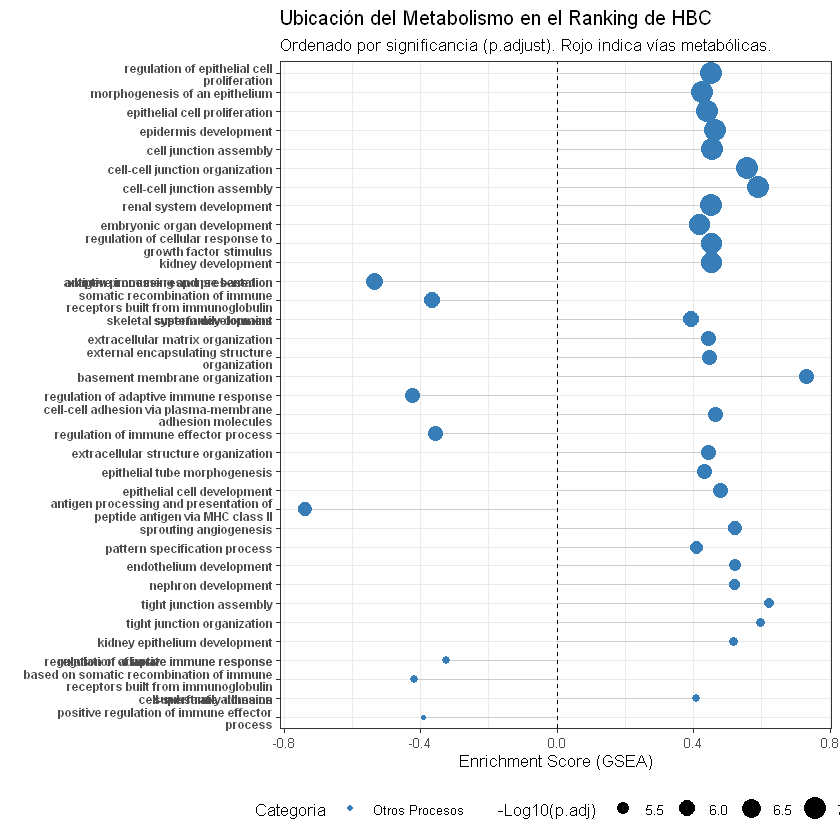

In [25]:
# %% [markdown]
# # Ranking de Vías: ¿Qué tan importantes son las metabólicas en HBC?

# %%
library(ggplot2)
library(dplyr)
library(stringr)

# 1. Preparar los datos: Top 30 vías por p-valor ajustado
df_ranking_hbc <- as.data.frame(gsea_go_hbc) %>%
  arrange(p.adjust) %>% 
  head(35) # Miramos las 35 mejores

# 2. Definir cuáles son metabólicas para resaltarlas
palabras_clave <- "metabol|glycol|lipid|fatty acid|oxphos|mitochondri"
df_ranking_hbc <- df_ranking_hbc %>%
  mutate(
    Es_Metabolica = grepl(palabras_clave, Description, ignore.case = TRUE),
    Categoria = ifelse(Es_Metabolica, "Metabolismo (Foco Tesis)", "Otros Procesos"),
    # Acortamos nombres para que no rompan el gráfico
    Short_Desc = str_wrap(Description, width = 40)
  )

# 3. Gráfico tipo Lollipop mejorado
plot_ranking <- ggplot(df_ranking_hbc, aes(x = reorder(Short_Desc, -p.adjust), y = enrichmentScore)) +
  # Línea de fondo
  geom_segment(aes(xend = Short_Desc, yend = 0), color = "grey80", size = 0.5) +
  # Los puntos (chupetines)
  geom_point(aes(color = Categoria, size = -log10(p.adjust))) +
  # Colores: Rojo fuerte para metabolismo, Gris para el resto
  scale_color_manual(values = c("Metabolismo (Foco Tesis)" = "#E41A1C", "Otros Procesos" = "#377EB8")) +
  # Línea en el cero
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  coord_flip() +
  theme_bw(base_size = 10) +
  labs(
    title = "Ubicación del Metabolismo en el Ranking de HBC",
    subtitle = "Ordenado por significancia (p.adjust). Rojo indica vías metabólicas.",
    x = "", y = "Enrichment Score (GSEA)",
    size = "-Log10(p.adj)"
  ) +
  theme(
    axis.text.y = element_text(size = 7, face = "bold"),
    legend.position = "bottom"
  )

print(plot_ranking)

# Exportar en tamaño grande para que no se pise nada
ggsave(file.path(base_dir, "Ranking_Metabolico_HBC.pdf"), plot = plot_ranking, width = 10, height = 12)

In [29]:
# %% [markdown]
# # Exportación Final Corregida (Evitando conflicto de select)

# %%
library(dplyr)
library(writexl)

# 1. Convertir los objetos de GSEA a dataframes
res_mim_vias <- as.data.frame(gsea_go) %>% mutate(Celulas = "Monocitos (MIM)")
res_hbc_vias <- as.data.frame(gsea_go_hbc) %>% mutate(Celulas = "Hofbauer (HBC)")

# 2. Unirlos y usar dplyr::select para evitar el error
vias_totales <- bind_rows(res_mim_vias, res_hbc_vias) %>%
  mutate(Enriquecido_En = ifelse(enrichmentScore > 0, "Femenino", "Masculino")) %>%
  # Especificamos que queremos el select de dplyr
  dplyr::select(Celulas, Enriquecido_En, ID, Description, enrichmentScore, pvalue, p.adjust, qvalue, setSize, core_enrichment)

# 3. Guardar en CSV
write.csv(vias_totales, file.path(base_dir, "GSEA_Resultados_Completos_Fran.csv"), row.names = FALSE)

# 4. Guardar en Excel
lista_excel <- list(
  "Resultados_Unidos" = vias_totales,
  "Solo_MIM" = res_mim_vias,
  "Solo_HBC" = res_hbc_vias
)

write_xlsx(lista_excel, path = file.path(base_dir, "GSEA_Vias_Significativas_Tesis.xlsx"))

cat("¡Ahora sí! Archivos generados correctamente.\n")

¡Ahora sí! Archivos generados correctamente.


In [30]:
# %% [markdown]
# # Filtrado Estricto de Vías (p.adjust < 0.05) y Re-exportación

# %%
library(dplyr)
library(writexl)

# 1. Aplicamos el filtro estricto a cada set
vias_mim_clean <- as.data.frame(gsea_go) %>% 
  filter(p.adjust < 0.05) %>%
  mutate(Celulas = "Monocitos (MIM)")

vias_hbc_clean <- as.data.frame(gsea_go_hbc) %>% 
  filter(p.adjust < 0.05) %>%
  mutate(Celulas = "Hofbauer (HBC)")

# 2. Unimos para el CSV Maestro
vias_totales_clean <- bind_rows(vias_mim_clean, vias_hbc_clean) %>%
  mutate(Enriquecido_En = ifelse(enrichmentScore > 0, "Femenino", "Masculino")) %>%
  dplyr::select(Celulas, Enriquecido_En, ID, Description, enrichmentScore, 
                p.adjust, setSize, core_enrichment)

# 3. Guardamos los archivos filtrados
write.csv(vias_totales_clean, 
          file = file.path(base_dir, "GSEA_Vias_FILTRADAS_Fran.csv"), 
          row.names = FALSE)

write_xlsx(list("Todo_Filtrado" = vias_totales_clean, 
                "MIM_Sig" = vias_mim_clean, 
                "HBC_Sig" = vias_hbc_clean), 
           path = file.path(base_dir, "GSEA_Vias_FILTRADAS_Tesis.xlsx"))

# 4. Chequeo rápido por consola
cat("--- RESUMEN DE VÍAS SIGNIFICATIVAS ---\n")
cat("Monocitos (MIM):", nrow(vias_mim_clean), "vías.\n")
cat("Hofbauer (HBC):", nrow(vias_hbc_clean), "vías.\n")

--- RESUMEN DE VÍAS SIGNIFICATIVAS ---
Monocitos (MIM): 1253 vías.
Hofbauer (HBC): 758 vías.


In [31]:
# %% [markdown]
# # Exportación Individual por Tipo Celular (Filtro p.adjust < 0.05)

# %%
library(dplyr)
library(writexl)

# 1. Procesamos Monocitos (MIM)
vias_mim_sig <- as.data.frame(gsea_go) %>% 
  filter(p.adjust < 0.05) %>%
  mutate(Enriquecido_En = ifelse(enrichmentScore > 0, "Femenino", "Masculino")) %>%
  dplyr::select(Enriquecido_En, ID, Description, enrichmentScore, p.adjust, setSize, core_enrichment)

# 2. Procesamos Hofbauer (HBC)
vias_hbc_sig <- as.data.frame(gsea_go_hbc) %>% 
  filter(p.adjust < 0.05) %>%
  mutate(Enriquecido_En = ifelse(enrichmentScore > 0, "Femenino", "Masculino")) %>%
  dplyr::select(Enriquecido_En, ID, Description, enrichmentScore, p.adjust, setSize, core_enrichment)

# --- EXPORTAR MONOCITOS (MIM) ---
write.csv(vias_mim_sig, file.path(base_dir, "GSEA_MIM_Significativo_Fran.csv"), row.names = FALSE)
write_xlsx(vias_mim_sig, path = file.path(base_dir, "GSEA_MIM_Significativo_Fran.xlsx"))

# --- EXPORTAR HOFBAUER (HBC) ---
write.csv(vias_hbc_sig, file.path(base_dir, "GSEA_HBC_Significativo_Fran.csv"), row.names = FALSE)
write_xlsx(vias_hbc_sig, path = file.path(base_dir, "GSEA_HBC_Significativo_Fran.xlsx"))

cat("¡Listo! Archivos separados generados:\n",
    "- GSEA_MIM_Significativo_Fran (.csv y .xlsx)\n",
    "- GSEA_HBC_Significativo_Fran (.csv y .xlsx)\n")

# Chequeo final de cuántas quedaron
print(paste("Vías MIM:", nrow(vias_mim_sig)))
print(paste("Vías HBC:", nrow(vias_hbc_sig)))

¡Listo! Archivos separados generados:
 - GSEA_MIM_Significativo_Fran (.csv y .xlsx)
 - GSEA_HBC_Significativo_Fran (.csv y .xlsx)
[1] "Vías MIM: 1253"
[1] "Vías HBC: 758"


In [33]:
# Esta función guarda ABSOLUTAMENTE TODO lo que tenés en el Environment ahora mismo
save.image(file = file.path(base_dir, "Sesion_Completa_GSEA_Fran.RData"))

cat("--- TODA LA SESIÓN GUARDADA ---\n")
cat("Archivo: Sesion_Completa_GSEA_Fran.RData\n")
cat("La próxima vez solo hacés load() de este archivo y listo.")

--- TODA LA SESIÓN GUARDADA ---
Archivo: Sesion_Completa_GSEA_Fran.RData
La próxima vez solo hacés load() de este archivo y listo.

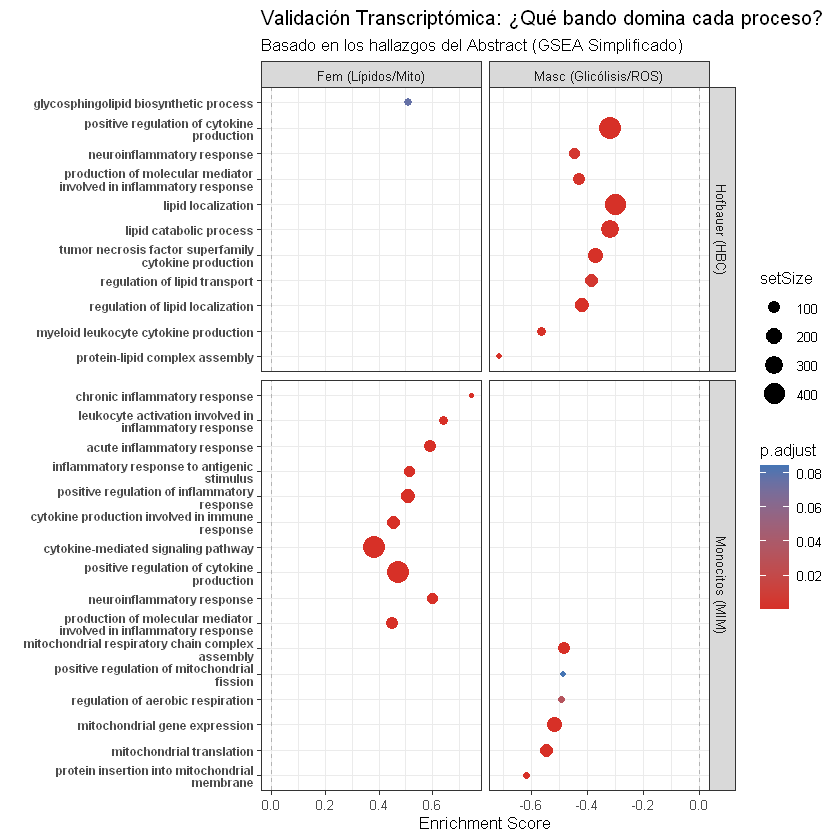

In [34]:
# %% [markdown]
# # GSEA Simplificado: Validación del Abstract sin Redundancia

# %%
library(clusterProfiler)
library(dplyr)
library(stringr)
library(ggplot2)

# 1. ELIMINAR REDUNDANCIA (Deduplicación inteligente)
# Esto compara las vías y si se solapan mucho, deja solo la más importante.
gsea_mim_simple <- simplify(gsea_go, cutoff = 0.7, by = "p.adjust", select_fun = min)
gsea_hbc_simple <- simplify(gsea_go_hbc, cutoff = 0.7, by = "p.adjust", select_fun = min)

# 2. FILTRO BASADO EN EL ABSTRACT
# Masc (M-pEVs): Glicólisis, ROS, Inflamación, IL-1
# Fem (F-pEVs): Ácidos grasos, Lípidos, Mitocondria, IL-10
tags_masc <- "glycoly|reactive oxygen|oxidative stress|inflammatory|interleukin-1|IL1|cytokine"
tags_fem  <- "fatty acid|lipid|mitochondrial|respiration|electron transport|IL10|regulatory"

# --- FUNCIÓN PARA FILTRAR Y PREPARAR ---
preparar_vias_abstract <- function(gsea_obj, nombre_celula) {
  df <- as.data.frame(gsea_obj) %>%
    filter(grepl(tags_masc, Description, ignore.case = TRUE) | 
           grepl(tags_fem, Description, ignore.case = TRUE)) %>%
    mutate(
      Tipo = ifelse(enrichmentScore < 0, "Masc (Glicólisis/ROS)", "Fem (Lípidos/Mito)"),
      Celulas = nombre_celula
    ) %>%
    group_by(Tipo) %>%
    slice_min(order_by = p.adjust, n = 10) %>% # Top 10 de cada bando
    ungroup()
  return(df)
}

# 3. PROCESAR AMBOS TIPOS CELULARES
df_mim_clean <- preparar_vias_abstract(gsea_mim_simple, "Monocitos (MIM)")
df_hbc_clean <- preparar_vias_abstract(gsea_hbc_simple, "Hofbauer (HBC)")

df_final <- bind_rows(df_mim_clean, df_hbc_clean)

# 4. GRAFICAR
# Envolvemos el texto para que quede prolijo
df_final$Description <- str_wrap(df_final$Description, width = 40)

ggplot(df_final, aes(x = enrichmentScore, y = reorder(Description, enrichmentScore))) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey70") +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#D73027", high = "#4575B4") + # Rojo a Azul
  facet_grid(Celulas ~ Tipo, scales = "free", space = "free_y") +
  theme_bw(base_size = 10) +
  labs(title = "Validación Transcriptómica: ¿Qué bando domina cada proceso?",
       subtitle = "Basado en los hallazgos del Abstract (GSEA Simplificado)",
       x = "Enrichment Score", y = "") +
  theme(axis.text.y = element_text(face = "bold", size = 7))

# Guardamos el resultado final limpio
# ggsave(file.path(base_dir, "Validacion_Abstract_Limpio.pdf"), width = 12, height = 10)

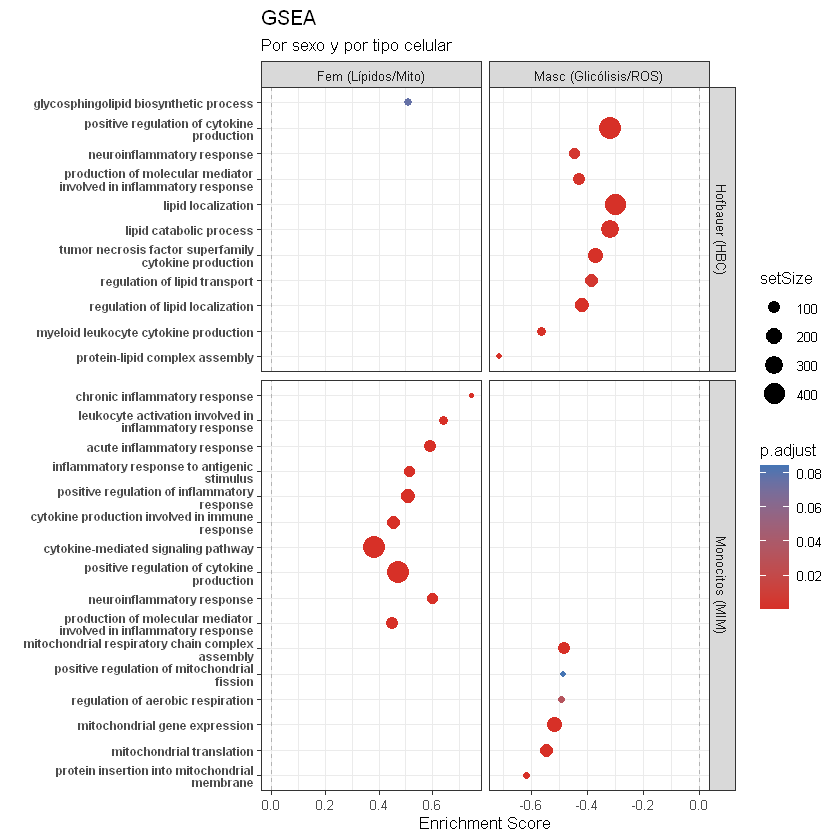

In [35]:
# 4. GRAFICAR
# Envolvemos el texto para que quede prolijo
df_final$Description <- str_wrap(df_final$Description, width = 40)

ggplot(df_final, aes(x = enrichmentScore, y = reorder(Description, enrichmentScore))) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey70") +
  geom_point(aes(size = setSize, color = p.adjust)) +
  scale_color_gradient(low = "#D73027", high = "#4575B4") + # Rojo a Azul
  facet_grid(Celulas ~ Tipo, scales = "free", space = "free_y") +
  theme_bw(base_size = 10) +
  labs(title = "GSEA",
       subtitle = "Por sexo y por tipo celular",
       x = "Enrichment Score", y = "") +
  theme(axis.text.y = element_text(face = "bold", size = 7))

# Guardamos el resultado final limpio
# ggsave(file.path(base_dir, "Validacion_Abstract_Limpio.pdf"), width = 12, height = 10)